In [1]:
import geopandas as gpd
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Carichiamo i quartieri con i dati di accessibilità già calcolati
buurten = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\geojson_lnglat_2.json")
buurten_proj = buurten.to_crs("EPSG:28992")

# Ricarichiamo il file di temperatura
st_path = r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\LC08_L2SP_198024_20240811_20240815_02_T1_ST_B10.TIF"

print("Dataset caricati!")
print(f"Quartieri: {len(buurten_proj)}")

Dataset caricati!
Quartieri: 518


In [2]:
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.windows import from_bounds
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Carichiamo il verde
green = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\park_geojson_lnglat.json", 
                      on_invalid="ignore")
green_proj = green.to_crs("EPSG:28992")

# Buffer 500m parchi
buffer_union = green_proj.geometry.buffer(500).union_all()

# Accessibilità per quartiere
buurten_proj['area_totale'] = buurten_proj.geometry.area
buurten_proj['area_coperta'] = buurten_proj.geometry.intersection(buffer_union).area
buurten_proj['accessibilita'] = (buurten_proj['area_coperta'] / buurten_proj['area_totale'] * 100).round(1)

print("Accessibilità calcolata!")
print(f"Media città: {buurten_proj['accessibilita'].mean():.1f}%")

Accessibilità calcolata!
Media città: 72.2%


In [3]:
# Leggiamo tutto il raster in memoria una volta sola
with rasterio.open(st_path) as src:
    st_raw = src.read(1).astype(float)
    raster_transform = src.transform
    raster_crs = src.crs

# Convertiamo i quartieri nel CRS del raster
buurten_raster = buurten_proj.to_crs(raster_crs)

# Per ogni quartiere troviamo i pixel corrispondenti
temps = []

for idx, row in buurten_raster.iterrows():
    bounds = row.geometry.bounds
    
    # Finestra del raster per questo quartiere
    col_start = max(0, int((bounds[0] - raster_transform.c) / raster_transform.a))
    col_end = min(st_raw.shape[1], int((bounds[2] - raster_transform.c) / raster_transform.a) + 1)
    row_start = max(0, int((bounds[3] - raster_transform.f) / raster_transform.e))
    row_end = min(st_raw.shape[0], int((bounds[1] - raster_transform.f) / raster_transform.e) + 1)
    
    chunk = st_raw[row_start:row_end, col_start:col_end]
    valid = chunk[chunk > 0]
    
    if len(valid) > 10:
        temp_c = valid * 0.00341802 + 149.0 - 273.15
        temps.append(temp_c.mean())
    else:
        temps.append(np.nan)

buurten_proj['temp_media'] = temps
valid_count = buurten_proj['temp_media'].notna().sum()
print(f"Temperature calcolate per {valid_count} quartieri")
print(f"Temperatura media: {buurten_proj['temp_media'].mean():.1f}°C")

Temperature calcolate per 518 quartieri
Temperatura media: 29.3°C


In [4]:
# Rimuoviamo outlier (Weesp, Westpoort)
df = buurten_proj[~buurten_proj['Stadsdeel'].isin(['Weesp', 'Westpoort'])].copy()
df = df.dropna(subset=['accessibilita', 'temp_media'])

# Correlazione
r, p = stats.pearsonr(df['accessibilita'], df['temp_media'])
print(f"Correlazione accessibilità vs temperatura:")
print(f"r = {r:.3f}")
print(f"p = {p:.6f}")

Correlazione accessibilità vs temperatura:
r = -0.015
p = 0.736097


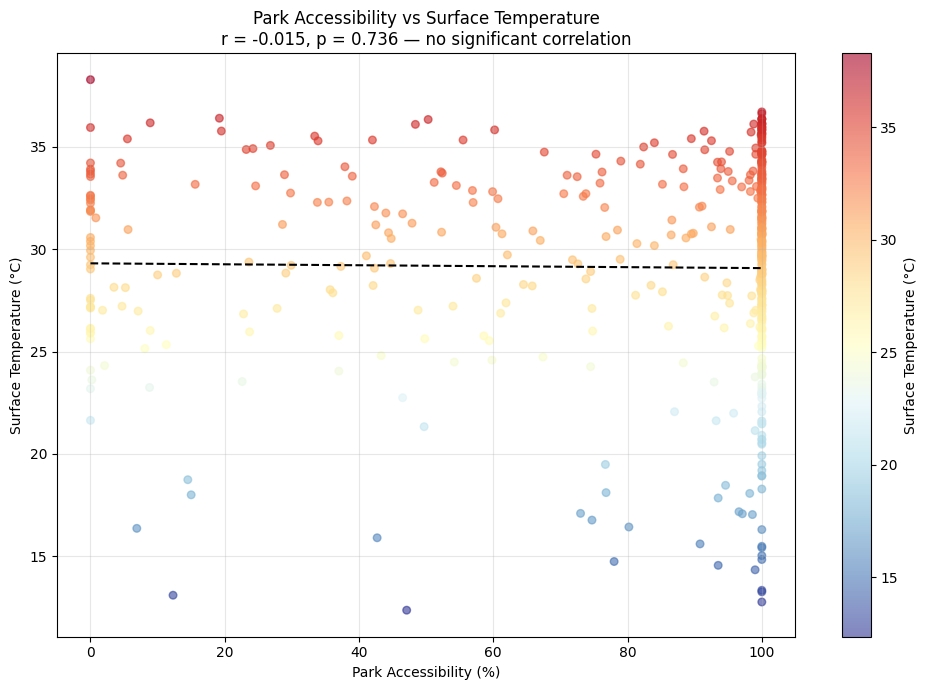

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    df['accessibilita'], 
    df['temp_media'],
    c=df['temp_media'],
    cmap='RdYlBu_r',
    s=30,
    alpha=0.6
)

# Linea di trend
z = np.polyfit(df['accessibilita'], df['temp_media'], 1)
x_line = np.linspace(df['accessibilita'].min(), df['accessibilita'].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), '--', color='black', linewidth=1.5)

plt.colorbar(scatter, ax=ax, label='Surface Temperature (°C)')
ax.set_xlabel('Park Accessibility (%)')
ax.set_ylabel('Surface Temperature (°C)')
ax.set_title(f'Park Accessibility vs Surface Temperature\nr = {r:.3f}, p = {p:.3f} — no significant correlation', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('amsterdam_accessibility_temperature.png', dpi=150, bbox_inches='tight')
plt.show()